d:\Manman\anaconda3\envs\glaft\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Successfully loaded offset1: (1177, 6) rows
  L8value: mean=0.088, std=6.905
  L9value: mean=0.184, std=5.638
Successfully loaded offset2: (1180, 6) rows
  L8value: mean=-0.853, std=4.543
  L9value: mean=-0.734, std=3.912
Successfully loaded offset3: (1178, 6) rows
  L8value: mean=0.203, std=7.228
  L9value: mean=0.997, std=14.612
Successfully loaded offset4: (1174, 6) rows
  L8value: mean=0.698, std=4.506
  L9value: mean=1.078, std=6.217

Processing offset1:
Original data: 1177 rows
Cycle 1: detected 7 outliers
Cycle 2: detected 34 outliers
Cycle 3: detected 27 outliers
Cleaned data: 1109 rows

Processing offset2:
Original data: 1180 rows
Cycle 1: detected 3 outliers
Cycle 2: detected 44 outliers
Cycle 3: detected 26 outliers
Cleaned data: 1107 rows

Processing offset3:
Original data: 1178 rows
Cycle 1: detected 13 outliers
Cycle 2: detected 26 outliers
Cycle 3: detected 22 outliers
Cleaned data: 1117 rows

Processing offset4:
Original data: 1174 rows
Cycle 1: detected 7 outliers
Cycl

C:\Users\DELL\AppData\Local\Temp\ipykernel_36960\3480035764.py:288: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



Figure saved to: D:\yan2\thesis\figure\S2\Ice\difference_analysis.png
Statistical results saved to: D:\yan2\thesis\figure\S2\Ice\statistical_results.csv
Difference analysis results saved to: D:\yan2\thesis\figure\S2\Ice\difference_results.csv

                        Summary Report

Data overview:
Total original samples: 4709
Total cleaned samples: 4455
Outlier removal rate: 5.39%

Sample size per group:
  offset1: 1177 → 1109 (removed 5.8%)
  offset2: 1180 → 1107 (removed 6.2%)
  offset3: 1178 → 1117 (removed 5.2%)
  offset4: 1174 → 1122 (removed 4.4%)

Statistical test summary:
  offset1: t = -0.339, p = 0.735 ns, d = -0.014 (negligible)
  offset2: t = 0.064, p = 0.949 ns, d = 0.003 (negligible)
  offset3: t = 0.833, p = 0.405 ns, d = 0.035 (negligible)
  offset4: t = -0.102, p = 0.919 ns, d = -0.004 (negligible)

Difference analysis summary:
  offset1: |L9|-|L8| = -0.011 ± 0.334 (range: -1.971 to 1.751)
  offset2: |L9|-|L8| = -0.022 ± 0.485 (range: -3.259 to 2.836)
  offset3: |L9|-

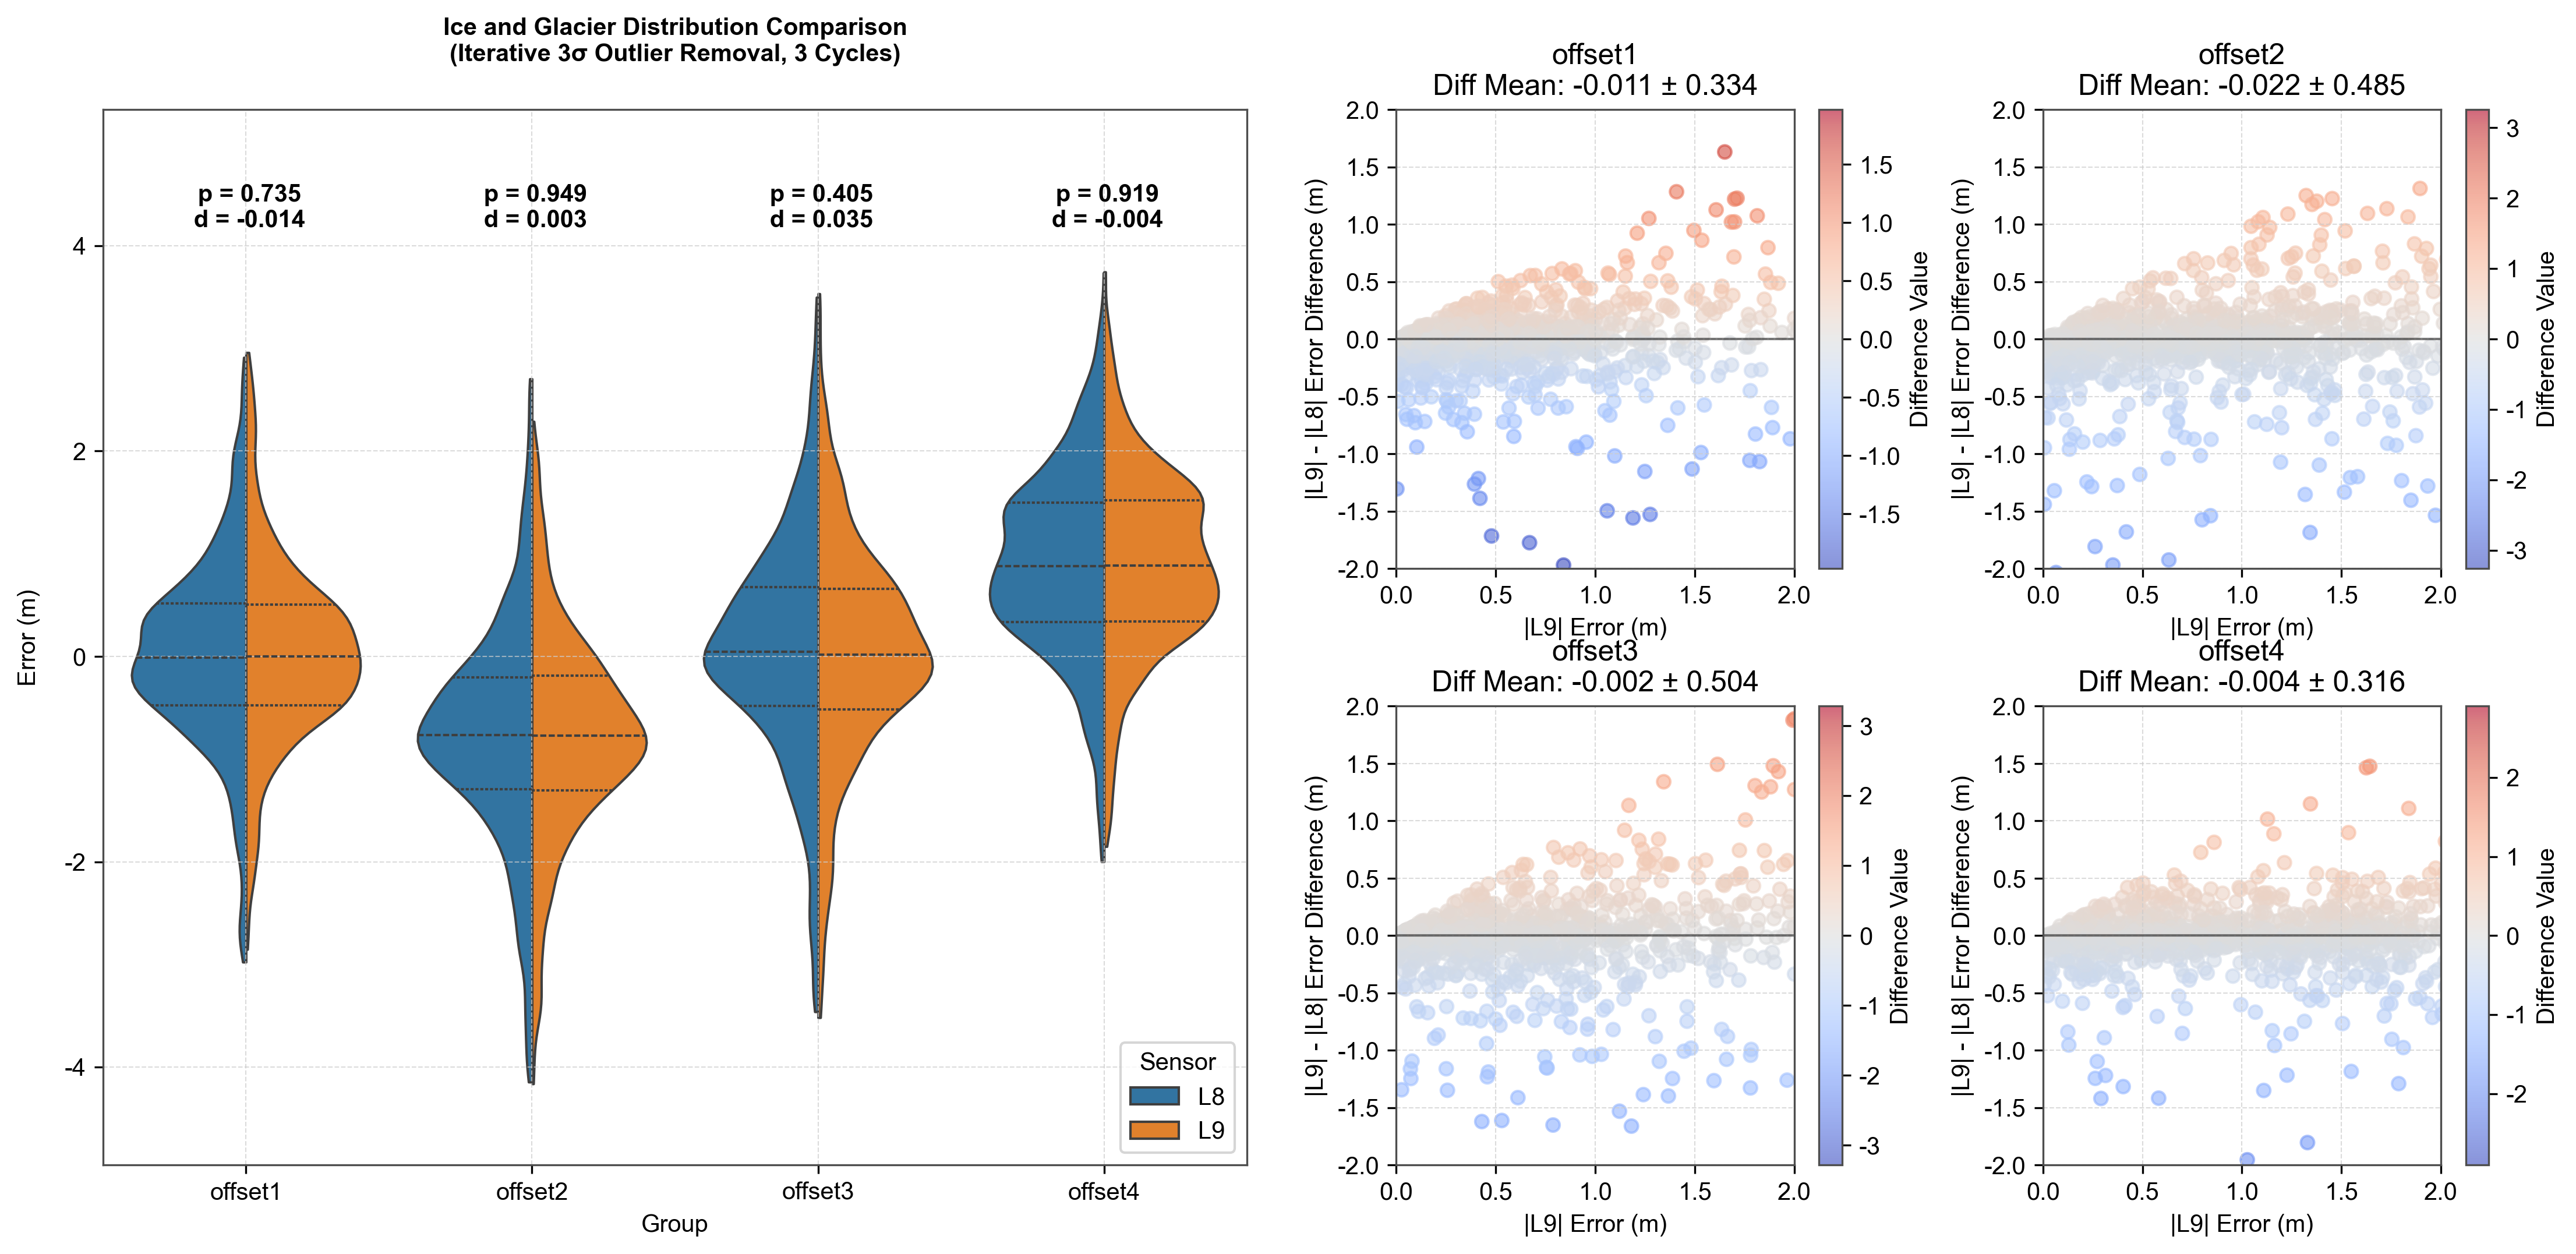

In [ ]:
# ======================== Merge bands and perform calculation ====================== Calculate vv and velocity
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, pearsonr
import scipy.stats as stats

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 16
plt.rcParams['axes.unicode_minus'] = False

# -----------------------------
# Helper function definitions
# -----------------------------

def cohens_d(x, y):
    """Calculate Cohen's d effect size"""
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    return (np.mean(x) - np.mean(y)) / np.sqrt(((nx-1)*np.std(x, ddof=1)**2 + (ny-1)*np.std(y, ddof=1)**2) / dof)

def remove_outliers_3sigma(df, column1, column2, cycles=3):
    """Iteratively remove outliers using 3-sigma rule"""
    df_clean = df.copy()
    
    for cycle in range(cycles):
        # Calculate standard deviation
        std1 = df_clean[column1].std()
        std2 = df_clean[column2].std()
        
        # Calculate mean
        mean1 = df_clean[column1].mean()
        mean2 = df_clean[column2].mean()
        
        # Define thresholds
        threshold1_low = mean1 - 3 * std1
        threshold1_high = mean1 + 3 * std1
        threshold2_low = mean2 - 3 * std2
        threshold2_high = mean2 + 3 * std2
        
        # Identify outliers
        outliers_mask = (
            (df_clean[column1] < threshold1_low) | (df_clean[column1] > threshold1_high) |
            (df_clean[column2] < threshold2_low) | (df_clean[column2] > threshold2_high)
        )
        
        print(f"Cycle {cycle + 1}: detected {outliers_mask.sum()} outliers")
        
        # Remove outliers
        df_clean = df_clean[~outliers_mask]
        
        if outliers_mask.sum() == 0:
            break
    
    return df_clean

# -----------------------------
# 1. Read offset1-4 files
# -----------------------------

file_path = r"\Ice"
files = [
    "ice_offset1_30_sample.csv",
    "ice_offset2_30_sample.csv", 
    "ice_offset3_30_sample.csv",
    "ice_offset4_30_sample.csv"
]

# Read all files
dataframes = {}
for i, file in enumerate(files, 1):
    file_full_path = os.path.join(file_path, file)
    try:
        df = pd.read_csv(file_full_path)
        dataframes[f'offset{i}'] = df
        print(f"Successfully loaded offset{i}: {df.shape} rows")
        if 'L8value' in df.columns and 'L9value' in df.columns:
            print(f"  L8value: mean={df['L8value'].mean():.3f}, std={df['L8value'].std():.3f}")
            print(f"  L9value: mean={df['L9value'].mean():.3f}, std={df['L9value'].std():.3f}")
    except Exception as e:
        print(f"Error reading file {file}: {e}")

# -----------------------------
# 2. Data preprocessing and outlier removal
# -----------------------------

cleaned_dataframes = {}
all_data_for_plot = []

for name, df in dataframes.items():
    if 'L8value' in df.columns and 'L9value' in df.columns:
        print(f"\nProcessing {name}:")
        print(f"Original data: {len(df)} rows")
        
        # Remove outliers
        df_clean = remove_outliers_3sigma(df, 'L8value', 'L9value', cycles=3)
        cleaned_dataframes[name] = df_clean
        print(f"Cleaned data: {len(df_clean)} rows")
        
        # Prepare plotting data
        for _, row in df_clean.iterrows():
            all_data_for_plot.append({'Group': name, 'Sensor': 'L8', 'value': row['L8value']})
            all_data_for_plot.append({'Group': name, 'Sensor': 'L9', 'value': row['L9value']})

# Convert to DataFrame
all_df_clean = pd.DataFrame(all_data_for_plot)

# -----------------------------
# 3. Save cleaned files
# -----------------------------

output_path = file_path
for name, df_clean in cleaned_dataframes.items():
    output_file = os.path.join(output_path, f"{name}_cleaned.csv")
    df_clean.to_csv(output_file, index=False)
    print(f"Cleaned data saved to: {output_file}")

# -----------------------------
# 4. Calculate differences
# -----------------------------

diff_data = []
for name, df_clean in cleaned_dataframes.items():
    if 'L8value' in df_clean.columns and 'L9value' in df_clean.columns:
        df_clean['abs_diff'] = np.abs(df_clean['L9value']) - np.abs(df_clean['L8value'])
        
        l9_mean = df_clean['L9value'].mean()
        l9_std = df_clean['L9value'].std()
        df_clean['L9value_standardized'] = (df_clean['L9value'] - l9_mean) / l9_std
        
        diff_data.append({
            'Group': name,
            'df': df_clean,
            'L9_values': df_clean['L9value'],
            'L9_standardized': df_clean['L9value_standardized'],
            'abs_diff': df_clean['abs_diff'],
            'n': len(df_clean)
        })
        
        print(f"{name}: diff stats - mean={df_clean['abs_diff'].mean():.3f}, std={df_clean['abs_diff'].std():.3f}, n={len(df_clean)}")

# -----------------------------
# 5. Statistical tests
# -----------------------------

ttest_results = []
for name, df_clean in cleaned_dataframes.items():
    if 'L8value' in df_clean.columns and 'L9value' in df_clean.columns:
        l8_values = df_clean['L8value']
        l9_values = df_clean['L9value']
        
        try:
            print("Landsat 8 normality test: {}".format(stats.shapiro(l8_values)))
            print("Landsat 9 normality test: {}".format(stats.shapiro(l9_values)))
            print("Variance homogeneity test: {}".format(stats.levene(l8_values, l9_values)))

            stat, p = stats.ttest_ind(l8_values, l9_values)
            effect_size = cohens_d(l8_values, l9_values)
            
            if abs(effect_size) < 0.2:
                practical_sig = 'negligible'
            elif abs(effect_size) < 0.5:
                practical_sig = 'small'
            elif abs(effect_size) < 0.8:
                practical_sig = 'medium'
            else:
                practical_sig = 'large'
                
            if p < 0.001:
                sig = '***'
            elif p < 0.01:
                sig = '**'
            elif p < 0.05:
                sig = '*'
            else:
                sig = 'ns'

            ttest_results.append({
                "Group": name, 
                "t": stat, 
                "p": p, 
                "sig": sig,
                "effect_size": effect_size,
                "practical_significance": practical_sig,
                "n_pairs": len(l8_values)
            })
        except Exception as e:
            print(f"Error in t-test for {name}: {e}")

ttest_df = pd.DataFrame(ttest_results)
print("\nT-test results:")
print(ttest_df)

# -----------------------------
# 6. Plotting
# -----------------------------

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 10,
    'axes.linewidth': 0.8,
    'lines.linewidth': 1,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'axes.edgecolor': '0.3',
    'grid.color': '0.8',
    'grid.linestyle': '--',
    'grid.linewidth': 0.5
})

fig = plt.figure(figsize=(18, 8), dpi=300)
gs = fig.add_gridspec(2, 4, hspace=0.3, wspace=0.3)

ax_violin = fig.add_subplot(gs[:, :2])

violin = sns.violinplot(
    data=all_df_clean,
    x="Group",
    y="value",
    hue="Sensor",
    split=True,
    inner="quart",
    linewidth=1,
    palette={"L8": "#1f77b4", "L9": "#ff7f0e"},
    density_norm="width",
    cut=0,
    bw_method=0.2,
    ax=ax_violin
)

y_max = all_df_clean["value"].max()
y_min = all_df_clean["value"].min()
y_range = y_max - y_min

for i, (_, row) in enumerate(ttest_df.iterrows()):
    y_pos = y_max + 0.05 * y_range
    label = f"\n p = {row['p']:.3f}\n d = {row['effect_size']:.3f}"
    
    ax_violin.text(
        i, y_pos, label,
        ha='center', va='bottom',
        fontsize=10, weight='bold',
        color='black'
    )

ax_violin.set_title("Ice and Glacier Distribution Comparison\n(Iterative 3σ Outlier Removal, 3 Cycles)", 
                   fontsize=10, weight='bold', pad=20)
ax_violin.set_ylabel("Error (m)", fontsize=10, labelpad=10)
ax_violin.legend(title="Sensor", title_fontsize=10, fontsize=10, 
                loc='lower right', frameon=True)
ax_violin.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax_violin.set_ylim(y_min - 0.1 * y_range, y_max + 0.2 * y_range)

ax_diff1 = fig.add_subplot(gs[0, 2])
ax_diff2 = fig.add_subplot(gs[0, 3])
ax_diff3 = fig.add_subplot(gs[1, 2])
ax_diff4 = fig.add_subplot(gs[1, 3])

diff_axes = [ax_diff1, ax_diff2, ax_diff3, ax_diff4]

for i, group_data in enumerate(diff_data):
    if i < len(diff_axes):
        ax = diff_axes[i]
        group = group_data['Group']
        l9_values = abs(group_data['L9_values'])
        abs_diff = group_data['abs_diff']
        
        scatter = ax.scatter(l9_values, abs_diff, alpha=0.6, s=30, c=abs_diff, 
                           cmap='coolwarm', vmin=-abs(abs_diff).max(), vmax=abs(abs_diff).max())

        ax.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)
        ax.set_xlim(0, 2)
        ax.set_ylim(-2, 2)
        
        diff_mean = abs_diff.mean()
        diff_std = abs_diff.std()
        
        ax.set_title(f'{group}\nDiff Mean: {diff_mean:.3f} ± {diff_std:.3f}')
        ax.set_xlabel('|L9| Error (m)')
        ax.set_ylabel('|L9| - |L8| Error Difference (m)')
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
        
        plt.colorbar(scatter, ax=ax, label='Difference Value')

plt.tight_layout()

# -----------------------------
# 7. Save outputs
# -----------------------------

output_fig_path = os.path.join(file_path, "difference_analysis.png")
plt.savefig(output_fig_path, bbox_inches='tight', dpi=300)
print(f"\nFigure saved to: {output_fig_path}")

output_stats_path = os.path.join(file_path, "statistical_results.csv")
ttest_df.to_csv(output_stats_path, index=False)
print(f"Statistical results saved to: {output_stats_path}")

diff_results = []
for group_data in diff_data:
    diff_results.append({
        'Group': group_data['Group'],
        'Diff_Mean': group_data['abs_diff'].mean(),
        'Diff_Std': group_data['abs_diff'].std(),
        'Diff_Min': group_data['abs_diff'].min(),
        'Diff_Max': group_data['abs_diff'].max(),
        'n': group_data['n']
    })

diff_df = pd.DataFrame(diff_results)
output_diff_path = os.path.join(file_path, "difference_results.csv")
diff_df.to_csv(output_diff_path, index=False)
print(f"Difference analysis results saved to: {output_diff_path}")

# -----------------------------
# 8. Summary report
# -----------------------------

print("\n" + "="*60)
print("                        Summary Report")
print("="*60)

print(f"\nData overview:")
total_original = sum(len(df) for df in dataframes.values())
total_cleaned = sum(len(df) for df in cleaned_dataframes.values())
removal_rate = (total_original - total_cleaned) / total_original * 100

print(f"Total original samples: {total_original}")
print(f"Total cleaned samples: {total_cleaned}")
print(f"Outlier removal rate: {removal_rate:.2f}%")

print(f"\nSample size per group:")
for name, df_clean in cleaned_dataframes.items():
    original_len = len(dataframes[name])
    cleaned_len = len(df_clean)
    removal_pct = (original_len - cleaned_len) / original_len * 100
    print(f"  {name}: {original_len} → {cleaned_len} (removed {removal_pct:.1f}%)")

print(f"\nStatistical test summary:")
for _, row in ttest_df.iterrows():
    print(f"  {row['Group']}: t = {row['t']:.3f}, p = {row['p']:.3f} {row['sig']}, "
          f"d = {row['effect_size']:.3f} ({row['practical_significance']})")

print(f"\nDifference analysis summary:")
for _, row in diff_df.iterrows():
    print(f"  {row['Group']}: |L9|-|L8| = {row['Diff_Mean']:.3f} ± {row['Diff_Std']:.3f} "
          f"(range: {row['Diff_Min']:.3f} to {row['Diff_Max']:.3f})")

print("\nAnalysis completed!")